<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Conversão de Taxa de Amostragem</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de Março de 2026
</div>

<div style="page-break-after: always;"></div>

<style>
#toc ol {
  counter-reset: item;
  list-style-type: none;
  padding-left: 1.2em;
}
#toc li {
  display: block;
}
#toc li:before {
  content: counters(item, ".") " ";
  counter-increment: item;
}
</style>

<div id="toc">
  <h2>Sumário</h2>
  <ol>
    <li><a href="#1-introdução">Introdução</a></li>
    <li>
      <a href="#2-desenvolvimento">Desenvolvimento</a>
      <ol>
          <li><a href="#21-decimate">Decimação via FFT</a></li>
          <li><a href="#22-upsample">Interpolação via FFT</a></li>
          <li><a href="#23-overlapandsave">Processamento com Overlap and Save</a></li>
          <li><a href="#24-resample">Conversão de Taxa Racional (Reamostragem)</a></li>
      </ol>
    </li>
    <li>
      <a href="#3-resultados-e-discussões">Resultados e discussões</a>
      <ol>
        <li><a href="#31-decimate">Decimação</a></li>
        <li><a href="#32-upsample">Interpolação</a></li>
        <li><a href="#3-resample">Reamostragem</a></li>
      </ol>
    </li>
    <li><a href="#4-conclusao">Conclusão</a></li>
    <li><a href="#referencias">Referências</a></li>
  </ol>
</div>

<div style="page-break-after: always;"></div>

<a id="1-introdução"></a>
# 1. Introdução

A alteração da taxa de amostragem de sinais discretos é uma operação fundamental no processamento digital de sinais, sendo essencial para a compatibilização de sistemas operando em frequências distintas ou para a redução do custo computacional. Este processo, genericamente denominado reamostragem, subdivide-se em duas operações principais: a **decimação**, que consiste na redução da taxa de amostragem, e a **interpolação**, que compreende o aumento da referida taxa. Enquanto a interpolação exige a reconstrução de amostras intermediárias sem a introdução de componentes espectrais espúrias, a decimação impõe a necessidade de uma filtragem anti-aliasing para preservar a integridade da banda passante original.

Neste trabalho, realizou-se a implementação de algoritmos de reamostragem fundamentados na Transformada Rápida de Fourier (FFT). Empregou-se a técnica de **Overlap-and-Save** associada ao tratamento de bordas por **padding de reflexão**, visando mitigar transientes decorrentes da natureza periódica da FFT e do efeito de Gibbs. A metodologia permitiu a conversão de taxas por fatores racionais arbitrários, garantindo alta precisão no domínio da frequência e fidelidade na reconstrução temporal do sinal.

<a id="2-desenvolvimento"></a>
# 2. Desenvolvimento

O sistema de reamostragem foi estruturado seguindo o modelo de cascata multirate, onde o sinal de entrada é submetido sequencialmente aos processos de interpolação e decimação.

<a id="21-decimate"></a>
## 2.2 Decimação e Filtragem Anti-Aliasing

A decimação por um fator $M$ define-se como o processo de redução da taxa de amostragem, o que implica na redução da nova frequência de Nyquist para $\pi/M$. Para evitar o fenômeno de sobreposição espectral (*aliasing*), implementou-se uma filtragem passa-baixas digital operando no domínio da frequência.

O filtro foi realizado através da truncagem seletiva dos coeficientes da DFT, eliminando-se todas as componentes de frequência superiores ao novo limite de banda permitido. Após a filtragem, o sinal foi convertido de volta ao domínio do tempo. Para manter a coerência da amplitude em relação ao sinal de entrada, aplicou-se uma normalização inversamente proporcional ao fator de decimação, corrigindo o ganho acumulado durante a soma das componentes espectrais na reconstrução.

A decimação é implementada a aprtir das funções `decimate_fft`, que retorna o sinal decimado para um sinal de entrada `x` e `decimate_overlap_save`, que utiliza do algoritmo do overlap and save para aplicar a função de decimação em blocos e uní-los. A última é utilizada na decimação de duas ondas senoidais amortecidas, e os sinais original e decimado são comparados visualmente no tempo e na frequ~encia normalizada.

<a id="22-upsample"></a>
## 2.2 Interpolação via Expansão Espectral (Upsampling)

A interpolação por um fator inteiro $L$ baseia-se no princípio de que a expansão de um sinal no domínio do tempo corresponde a uma compressão no domínio da frequência. O processo foi executado operando-se diretamente sobre os coeficientes da Transformada Discreta de Fourier (DFT).

Para elevar a taxa de amostragem, realizou-se o preenchimento de zeros (*zero-padding*) nas frequências correspondentes à zona de transição e às altas frequências do espectro original, expandindo o comprimento total do vetor. Este procedimento equivale à aplicação de um filtro passa-baixas ideal (filtro de interpolação) com frequência de corte normalizada igual a $\pi/L$. A reconstrução do sinal no domínio do tempo foi realizada através da Transformada Inversa (IDFT) escalonada. Este escalonamento é necessário para compensar a variação da densidade energética do sinal devido ao aumento do número de amostras, garantindo a preservação da amplitude original das componentes senoidais.

A interpolação é implementada a partir das funções `upsample_fft`, que retorna o sinal com taxa de amostragem elevada para um sinal de entrada x, e `upsample_overlap_save`, que utiliza o algoritmo overlap-and-save para aplicar a interpolação em blocos e uní-los de forma contínua. A última função é empregada na sobreamostragem de duasondas senoidais amortecidas, permitindo a comparação visual entre os sinais original e interpolado tanto no domínio do tempo quanto na frequência normalizada.

<a id="23-overlapandsave"></a>
## 2.3 Processamento por Blocos e Overlap-and-Save

Dada a impossibilidade prática de processar sinais longos em tempo real, utilizou-se o algoritmo **Overlap-and-Save**. Este método fundamenta-se na decomposição do sinal em blocos sobrepostos, permitindo que a convolução circular proveniente do produto entre os espectros do sinal e o filtro seja equaivalente à convolução linear.

As porções do sinal corrompidas pelo efeito da convolução circular nas extremidades de cada bloco foram descartadas, retendo-se apenas o segmento central válido. Complementarmente, aplicou-se o **padding por reflexão** nas bordas do sinal total. Esta técnica minimiza a descontinuidade entre o final do sinal e o início do seu espelhamento, reduzindo a magnitude dos lóbulos secundários e as oscilações típicas do efeito de Gibbs, que ocorrem quando funções com transições abruptas são truncadas no domínio da frequência.

<a id="24-resample"></a>
## 2.4 Conversão de Taxa por Fatores Racionais

A reamostragem por um fator racional $r = L/M$ foi implementada através de um sistema multirate em cascata. O algoritmo determina primeiramente os inteiros coprimos $L$ e $M$ através da simplificação da razão de reamostragem.

A ordem de execução — interpolação por $L$ seguida de decimação por $M$ — é uma exigência matemática para evitar a perda de informação. Ao realizar o *upsampling* primeiro, a largura de banda do sinal é preservada em uma taxa de amostragem intermediária elevada, permitindo que o filtro anti-aliasing da decimação subsequente atue com maior precisão e resolução espectral.

A reamostragem por fatores racionais é realizada pela função `resample_fft`, que consolida as etapas de interpolação e decimação de acordo com a razão $r = L/M$. O código identifica os inteiros coprimos $L$ e $M$ e executa a cascata multirate, chamando sequencialmente as funções `upsample_overlap_save` e `decimate_overlap_save`. Este procedimento é aplicado para converter o sinal entre taxas não inteiras, sendo os resultados validados por meio de análises temporais e espectrais. 

In [63]:
import numpy as np
from fractions import Fraction
import matplotlib.pyplot as plt
from scipy.signal import decimate, group_delay
import math
from scipy import signal
import sys
sys.path.append('./pds_utils')
import pds_utils as pds

np.random.seed(42)
plt.style.use('seaborn-v0_8')

In [ ]:
def decimate_fft(x, N, smooth = True):
    """ Decimate a signal by a factor of N using FFT.
    Parameters
    ----------
    x : array_like
        Input signal.
    N : int
        Decimation factor.
    n : int, optional
        Number of coefficients of the low-pass filter. If None, it will be set to 30*N.
    Returns
    -------
    y : ndarray
        Decimated signal.
    """
    y = []
    N_out = math.ceil(len(x) / N)


    #print(f"Decimation factor: {N}, Output length: {N_out}")
    X = np.fft.fftshift(np.fft.fft(x))
    f_0 = len(x)//2
    start_idx = f_0 - N_out//2


    X_decimate = X[start_idx : start_idx+N_out]
        
    #print(f"Decimated FFT length: {len(X_decimate)}")
    X_decimate = np.fft.ifftshift(X_decimate)
    x_decimate = np.fft.ifft(X_decimate)

    return x_decimate / N

def decimate_overlap_save(x, N, block_size=2048, overlap_factor=4):
    """
    Decimates a signal by a factor of N using the overlap-save method with FFT-based decimation.
    Paramters
    ----------
    x : ndarray
        Input signal.
    N : int
        Decimation factor.
    block_size : int, optional
        Size of each processing block. Should be a multiple of N for best performance.
    overlap_factor : int, optional
        Factor determining the overlap between blocks.
    Returns
    -------
    y : ndarray
        Decimated signal.
    """
    if block_size % N != 0:
        block_size = (block_size // N) * N
    
    overlap = block_size // overlap_factor
    overlap = (overlap // N) * N
    step = block_size - 2 * overlap  
    
    num_steps = int(np.ceil(len(x) / step))
    total_padding_end = (num_steps * step) - len(x) + overlap
    
    x_padded = np.pad(x, (overlap, total_padding_end), mode='reflect')
    
    y_final = []
    
    discard_out = overlap // N
    step_out = step // N

    for i in range(num_steps):
        start = i * step
        block = x_padded[start : start + block_size]
        
        y_block = decimate_fft(block, N)
        
        y_segment = y_block[discard_out : discard_out + step_out]
        y_final.append(y_segment)
    
    result = np.concatenate(y_final)
    
    return np.real(result[:int(np.ceil(len(x)/N))])

def upsample_fft(x, L):
    """
    Upsamples a signal by a factor of L using FFT-based interpolation.
    Parameters
    ----------
    x : array_like
        Input signal.
    L : int
        Upsampling factor.
    Returns
    -------
    y : ndarray
        Upsampled signal.
    """
    n = len(x)
    N_out = n * L
    X = np.fft.fft(x)
    
    Y = np.zeros(N_out, dtype=complex)

    mid = (n + 1) // 2
    Y[:mid] = X[:mid]
    
    if n % 2 == 0:
        nyquist_idx = n // 2
        Y[nyquist_idx] = X[nyquist_idx] / 2
        Y[N_out - nyquist_idx] = X[nyquist_idx] / 2
        Y[N_out - nyquist_idx + 1:] = X[nyquist_idx + 1:]
    else:
        Y[N_out - (n - mid):] = X[mid:]
        
    return np.fft.ifft(Y) * L

def upsample_overlap_save(x, L, block_size=1024, overlap_factor=4):
    """
    Upsamples a signal by a factor of L using FFT-based interpolation with overlap-save method.
    Parameters    
    ----------
    x : ndarray
        Input signal.
    L : int
        Upsampling factor.
    block_size : int, optional
        Size of each processing block.
    overlap_factor : int, optional
        Factor determining the overlap between blocks.

    Returns
    -------
    y : ndarray
        Upsampled signal.
    """
    overlap = block_size // overlap_factor
    step = block_size - 2 * overlap 
    
    x_padded = np.pad(x, (overlap, block_size), mode='reflect')
    
    y_final = []
    overlap_out = overlap * L
    step_out = step * L

    for i in range(0, len(x), step):
        block = x_padded[i : i + block_size]
        
        y_block = upsample_fft(block, L)
        
        y_segment = y_block[overlap_out : overlap_out + step_out]
        y_final.append(y_segment)
    
    result = np.concatenate(y_final)
    return np.real(result[:L * len(x)])

def resample_fft(x, r, block_size=2048):
    """
    Muda a taxa de amostragem de um sinal por um fator r = L/M.
    
    Parameters
    ----------
    x : array_like
        Sinal de entrada.
    r : float
        Fator de reamostragem (ex: 1.5, 0.75, 2).
    """
    frac = Fraction(r).limit_denominator()
    L, M = frac.numerator, frac.denominator
    
    #print(f"Reamostragem r={r} -> L={L}, M={M}")
    if L > 1:
        x_L = upsample_overlap_save(x, L, block_size=block_size)
    else:
        x_L = x  
    if M > 1:
        
        y = decimate_overlap_save(x_L, M, block_size=block_size)
    else:
        y = x_L
        
    return y

<a id="3-resultados"></a>
# 3 Resultados e Discussões

<a id="31-decimate"></a>
## 3.1 Decimação

C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_14684\3190873242.py:22: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 100, using nperseg = 100
  f_orig_norm, p_orig = signal.welch(x_n, fs=1.0, nperseg=128)


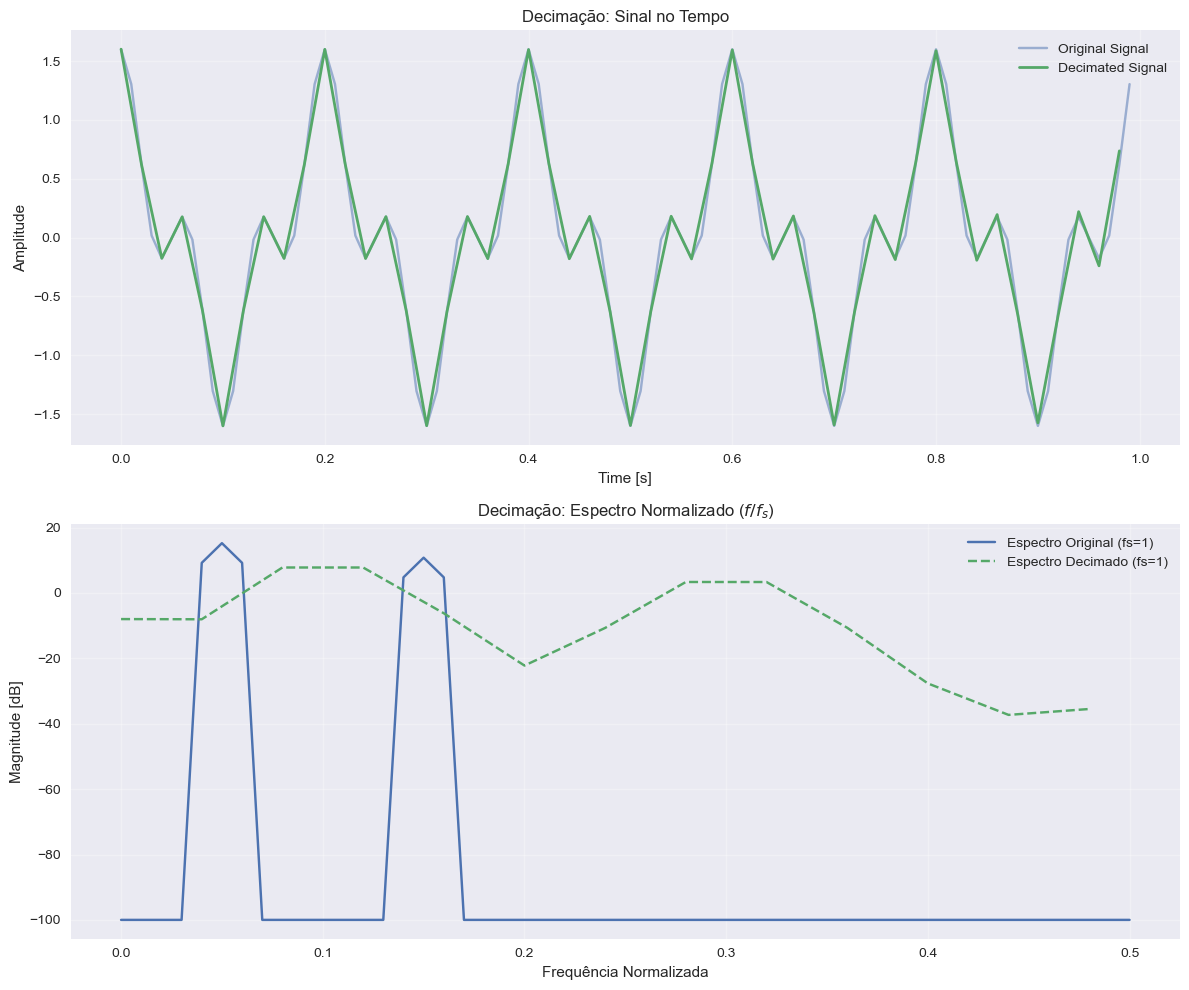

In [92]:
f_orig = 100
M = 2 
f_sinal = 5
T = 1

n = np.arange(0, T, 1/f_orig)
x_n = np.cos(2 * np.pi * f_sinal * n) + 0.6 * np.cos(2*np.pi*15*n)

x_decimate = decimate_overlap_save(x_n, M, block_size=256)
n_decimate = np.linspace(0, T, len(x_decimate), endpoint=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(n, x_n, label='Original Signal', alpha=0.5)
ax1.plot(n_decimate, x_decimate, label='Decimated Signal', linewidth=2)
ax1.set_title('Decimação: Sinal no Tempo')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

f_orig_norm, p_orig = signal.welch(x_n, fs=1.0, nperseg=128)
f_dec_norm, p_dec = signal.welch(x_decimate, fs=1.0, nperseg=len(x_decimate)//2)
ax2.plot(f_orig_norm, 10*np.log10(p_orig + 1e-10), label='Espectro Original (fs=1)')
ax2.plot(f_dec_norm, 10*np.log10(p_dec + 1e-10), '--', label='Espectro Decimado (fs=1)')
ax2.set_title('Decimação: Espectro Normalizado ($f/f_s$)')
ax2.set_xlabel('Frequência Normalizada')
ax2.set_ylabel('Magnitude [dB]')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()

---
A partir dos gráficos, pode-se perceber o efeito da decimação no espectro do sinal: O espectro se alarga devido à redução da taxa de amostragem. Esse fenômeno faz com que, caso o fator de decimação seja grande o suficiente, as cópias do sinal em torno dos múltiplos da frequência de amostragem se sobrepunham, causando *aliasin*. O método de decimação via FFT aplica um filtro passa-baixas ideal ao espectro do sinal, de modo que isso é evitado. Em decimações realizadas no domínio do tempo, é necessário a pré-filtragem do sinal, para atenuar as componentes de frequ~encia que poderiam se sobrepor ao reduzir a frequência de amostragem.

É possível observar também que o móduo do sinal decimado é liegeiramente menor que do sinal original. Esse fenômeno estyá diretamente associado ao alargamento do espectro. A energia do sinal não foi alterada, de modo que para representar a mesma energia em um espectro mais espalhado, o módulo decresça para conservar a energia do sinal.

<a id="32-upsample"></a>

## 3.2 Interpolação



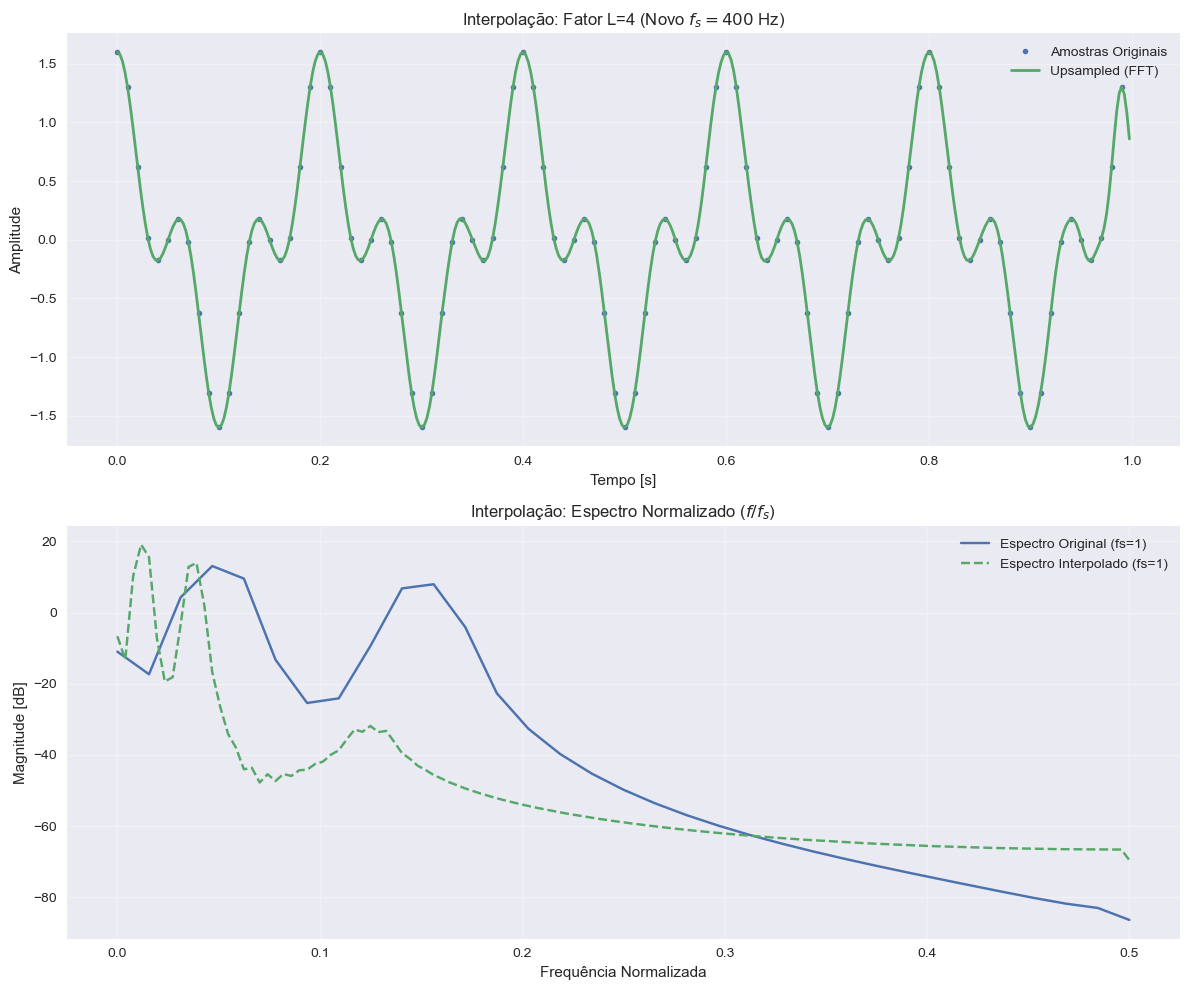

In [91]:
f_orig_up = 100
L = 4
f_sinal_up = 5
T_up = 1

n_up = np.arange(0, T_up, 1/f_orig_up)
x_n_up = (np.cos(2 * np.pi * f_sinal_up * n_up) + 0.6 *np.cos(2 * np.pi * 15 * n_up))

x_upsampled = upsample_overlap_save(x_n_up, L, block_size=64, overlap_factor=4)
n_upsampled = np.linspace(0, T_up, len(x_upsampled), endpoint=False)

fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 10))

ax3.plot(n_up, x_n_up, 'C0o', markersize=4, label='Amostras Originais')
ax3.plot(n_upsampled, x_upsampled, color='C1', linewidth=2, label='Upsampled (FFT)')
ax3.set_title(f'Interpolação: Fator L={L} (Novo $f_s = {f_orig_up * L}$ Hz)')
ax3.set_xlabel('Tempo [s]')
ax3.set_ylabel('Amplitude')
ax3.legend()
ax3.grid(True, alpha=0.3)

f_up_norm_orig, p_up_orig = signal.welch(x_n_up, fs=1.0, nperseg=64)
f_up_norm_res, p_up_res = signal.welch(x_upsampled, fs=1.0, nperseg=256)
ax4.plot(f_up_norm_orig, 10*np.log10(p_up_orig + 1e-10), label='Espectro Original (fs=1)')
ax4.plot(f_up_norm_res, 10*np.log10(p_up_res + 1e-10), '--', label='Espectro Interpolado (fs=1)')
ax4.set_title('Interpolação: Espectro Normalizado ($f/f_s$)')
ax4.set_xlabel('Frequência Normalizada')
ax4.set_ylabel('Magnitude [dB]')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

A partir dos gráficos gerados para análise de intepolação, é possível perceber os efeitos causados por esse processo. O primeiro efeito observado é a comressão do espectro do sinal original. Isso se dá pelo aumento da frequência de amostragem, e consequentemente, da escala do eixo da frequência normalizada. É possível notar também que o módulo do espectro aumenta, que se explica, de forma semelhante ao fenômeno inverso ocorrido na decimação, pela conservação da energia do sinal. 

Umm fenômeno interessante que surge na interpolação é o aparecimento de níveis de amplitude além das do espectro original que estavam dentro da faixa de frequências representada pela frequência de amostragem original. Ao interpolar o sinal, e aumentar a taxa de amostragem, as imagens espectrais do sinal original além da frequência de Nyquist são novamente representadas no novo eixo de frequência normalizada. Em interpolações no domínio do tempo, aplica-se um filtro passa baixas para atenuar essas réplicas. No método de interpolação por FFT, essa energia não é totalmente atenuada, o que pode causar distorções de alta frequência no sinal recuperado, caso sua amplitude se eleve muito.

<a id="33-resample"></a>
## 3.3 Reamostragem

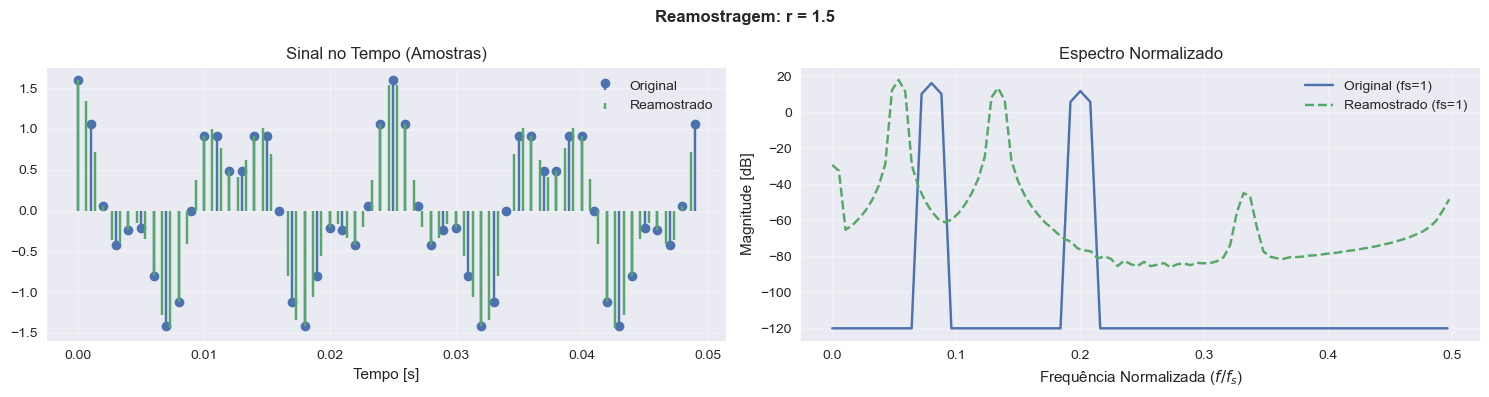

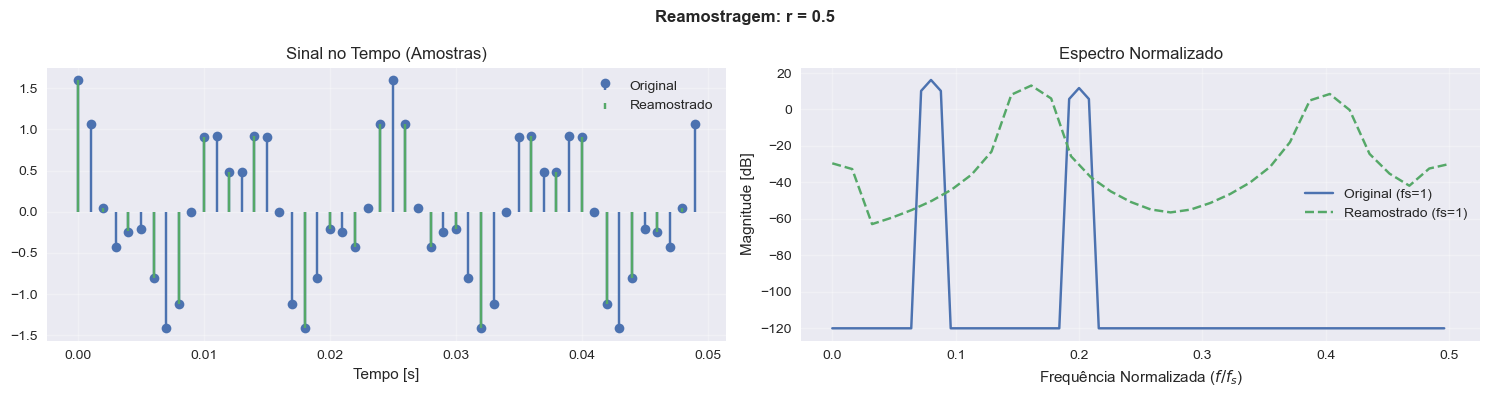

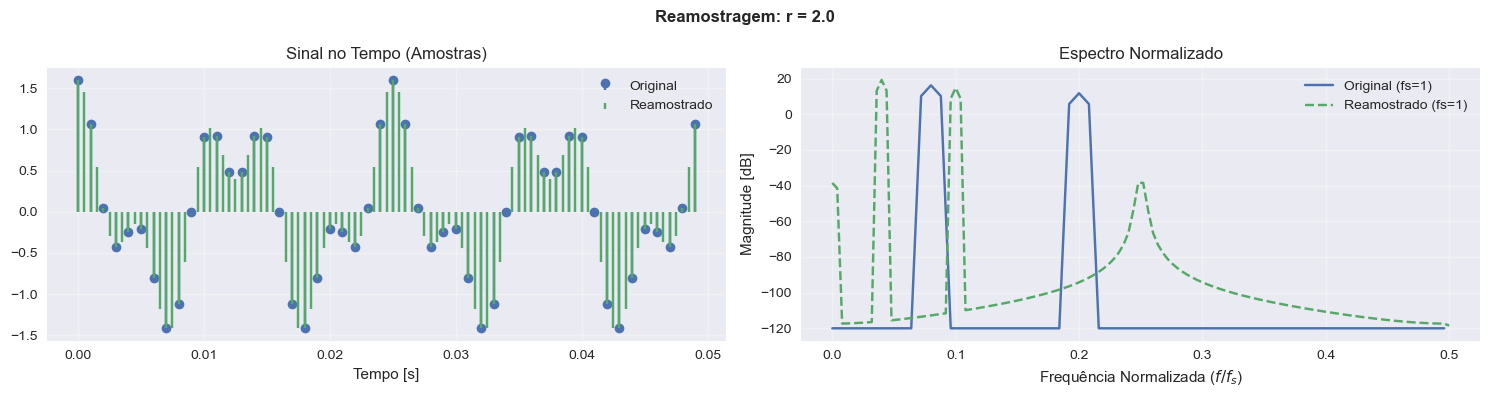

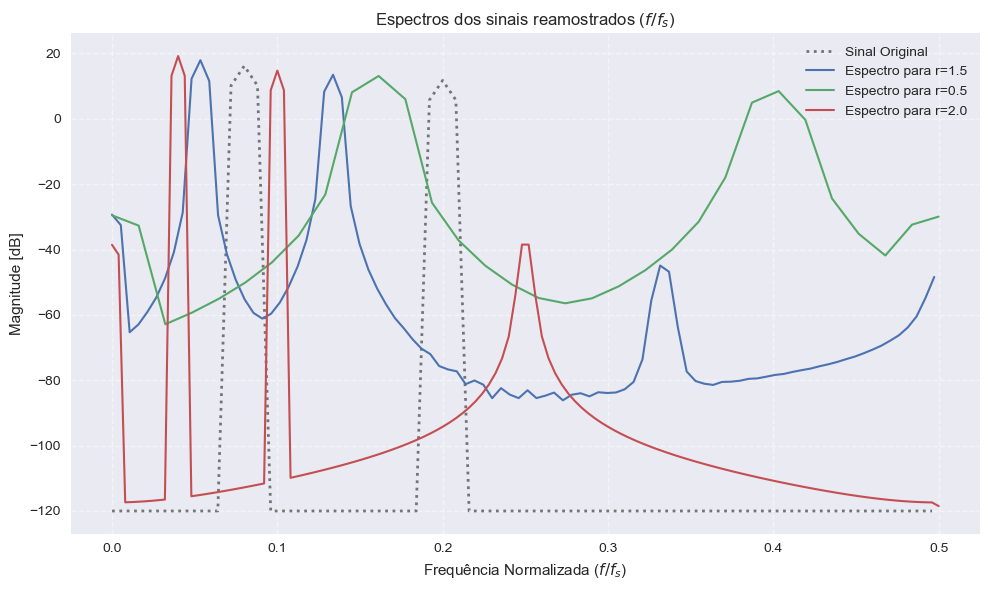

In [70]:
fs_orig = 1000.0
T = 0.5
f1, f2 = 80.0, 200.0 

t = np.arange(0, T, 1/fs_orig)
x_original = np.cos(2 * np.pi * f1 * t) + 0.6 * np.cos(2 * np.pi * f2 * t)

taxas = [1.5, 0.5, 2.0]
espectros_comparativos = []

for r in taxas:
    
    y_resampled = resample_fft(x_original, r, block_size=1024)
    
    fs_new = fs_orig * r
    t_new = np.arange(len(y_resampled)) / fs_new
    
    
    fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Reamostragem: r = {r}", fontsize=12, fontweight='bold')
    
    
    n_show = 50
    ax_t.stem(t[:n_show], x_original[:n_show], linefmt='C0-', markerfmt='C0o', 
              label='Original', basefmt=" ")

    mask_y = t_new <= t[n_show-1]
    ax_t.stem(t_new[mask_y], y_resampled[mask_y], linefmt='C1-', markerfmt='C1x', 
              label='Reamostrado', basefmt=" ")
    ax_t.set_title("Sinal no Tempo (Amostras)")
    ax_t.set_xlabel("Tempo [s]")
    ax_t.legend()
    ax_t.grid(True, alpha=0.3)
    
    
    f_norm_x, p_x = signal.welch(x_original, fs=1.0, nperseg=len(x_original)//4)
    f_norm_y, p_y = signal.welch(y_resampled, fs=1.0, nperseg=len(y_resampled)//4)
    
    ax_f.plot(f_norm_x, 10*np.log10(p_x + 1e-12), label='Original (fs=1)')
    ax_f.plot(f_norm_y, 10*np.log10(p_y + 1e-12), label='Reamostrado (fs=1)', 
              linestyle='--')
    ax_f.set_title("Espectro Normalizado")
    ax_f.set_xlabel("Frequência Normalizada ($f/f_s$)")
    ax_f.set_ylabel("Magnitude [dB]")
    ax_f.legend()
    ax_f.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    espectros_comparativos.append((f_norm_y, p_y, r))

plt.figure(figsize=(10, 6))


f_orig_ref, p_orig_ref = signal.welch(x_original, fs=1.0, nperseg=len(x_original)//4)
plt.plot(f_orig_ref, 10*np.log10(p_orig_ref + 1e-12), 'k:', linewidth=2, 
         label='Sinal Original', alpha=0.5)

for f, p, r in espectros_comparativos:
    plt.plot(f, 10*np.log10(p + 1e-12), label=f'Espectro para r={r}', linewidth=1.5)

plt.title("Espectros dos sinais reamostrados ($f/f_s$)")
plt.xlabel("Frequência Normalizada ($f/f_s$)")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

---

A partir dos gráficos, os efeitos de interpolação e decimação são novamente ilustrados. Caso o fator de conversão seja maior que 1, ou seja, o sinal é reamostrado a uma taxa maior, e os efeitos da interpolação dsicutidos são predominantes. Para taxas de conversão menores que 1, os efeits da decimação são predominantes.

<a id="4-conclusao"></a>
# 4. Conclusão

O desenvolvimento deste sistema de reamostragem via FFT demonstrou a viabilidade e a precisão da manipulação de taxas de amostragem no domínio da frequência. A decomposição de fatores racionais em componentes inteiras de interpolação e decimação permitiu uma flexibilidade operacional significativa, seguindo rigorosamente o fluxo lógico de processamento multirate.

Concluiu-se que o tratamento adequado das bordas dos blocos de dados é um fator crítico em algoritmos baseados na Transformada de Fourier. A transição do preenchimento de zeros para a técnica de reflexão foi o diferencial necessário para a obtenção de sinais no tempo isentos de artefatos espúrios. Por fim, os espectros normalizados confirmaram que a metodologia aplicada atua como um filtro de reconstrução e anti-aliasing de alto desempenho, essencial para aplicações de alta fidelidade em processamento digital de sinais.